In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [4]:
file_path = "weather_data.csv"
weather_df = pd.read_csv(file_path)

print(weather_df.describe())
weather_df.info()
weather_df.head(1000)

        Temperature      Humidity    Wind Speed  Precipitation (%)  \
count  13169.000000  13178.000000  13175.000000       13180.000000   
mean      19.098507     68.820079      9.814610          53.622281   
std       17.648473     21.247853      7.152796          32.322668   
min     -164.708050     20.000000    -94.138309        -231.786729   
25%        4.000000     57.000000      5.000000          19.000000   
50%       21.000000     70.000000      9.000000          58.000000   
75%       31.000000     84.000000     13.500000          82.000000   
max      154.355435    614.848415     69.469455         467.821581   

       Atmospheric Pressure  Visibility (km)   Irradiance  
count          13169.000000     13166.000000  1333.000000  
mean            1004.413619         5.454988   702.310397  
std              143.473226         3.516754     0.000000  
min            -9196.253993       -54.469352   702.310397  
25%              994.760000         3.000000   702.310397  
50%      

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type,Irradiance
0,14.0,73.0,9.5,82.0,partly cloudy,1010.82,2.0,Winter,3.5,inland,Rainy,NaN
1,39.0,96.0,8.5,71.0,partly cloudy,1011.43,7.0,Spring,10.0,inland,Cloudy,702.310397
2,30.0,64.0,7.0,16.0,clear,1018.72,5.0,Spring,5.5,mountain,Sunny,NaN
3,38.0,83.0,1.5,82.0,clear,1026.25,7.0,Spring,1.0,coastal,Sunny,NaN
4,27.0,74.0,17.0,66.0,overcast,990.67,1.0,Winter,2.5,mountain,Rainy,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
995,-2.0,69.0,10.0,64.0,overcast,983.29,0.0,Winter,4.5,mountain,Snowy,NaN
996,34.0,55.0,6.5,19.0,partly cloudy,1018.38,5.0,Autumn,7.5,inland,Sunny,NaN
997,28.0,91.0,8.5,86.0,clear,1029.24,6.0,Autumn,5.5,mountain,Sunny,NaN
998,-10.0,89.0,9.5,93.0,partly cloudy,982.68,0.0,Winter,3.5,mountain,Snowy,NaN


In [5]:
# kedze UV index by mali byt cisla, tak to prevedieme do numerickych hodnot
weather_df['UV Index'] = pd.to_numeric(weather_df['UV Index'], errors='coerce')

# počet koľko NaN hodnôt (neplatných) existuje
nan_count = weather_df['UV Index'].isna().sum()
print(nan_count)

stats = weather_df.describe()
print(stats)

# vsetky stringy by mali byt premenene na NaN, testovacia tabulka
weather_df.head(10120)

37
        Temperature      Humidity    Wind Speed  Precipitation (%)  \
count  13169.000000  13178.000000  13175.000000       13180.000000   
mean      19.098507     68.820079      9.814610          53.622281   
std       17.648473     21.247853      7.152796          32.322668   
min     -164.708050     20.000000    -94.138309        -231.786729   
25%        4.000000     57.000000      5.000000          19.000000   
50%       21.000000     70.000000      9.000000          58.000000   
75%       31.000000     84.000000     13.500000          82.000000   
max      154.355435    614.848415     69.469455         467.821581   

       Atmospheric Pressure      UV Index  Visibility (km)   Irradiance  
count          13169.000000  13176.000000     13166.000000  1333.000000  
mean            1004.413619      4.014814         5.454988   702.310397  
std              143.473226      3.892169         3.516754     0.000000  
min            -9196.253993    -12.700931       -54.469352   702.31039

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type,Irradiance
0,14.0,73.0,9.5,82.0,partly cloudy,1010.82,2.0,Winter,3.5,inland,Rainy,NaN
1,39.0,96.0,8.5,71.0,partly cloudy,1011.43,7.0,Spring,10.0,inland,Cloudy,702.310397
2,30.0,64.0,7.0,16.0,clear,1018.72,5.0,Spring,5.5,mountain,Sunny,NaN
3,38.0,83.0,1.5,82.0,clear,1026.25,7.0,Spring,1.0,coastal,Sunny,NaN
4,27.0,74.0,17.0,66.0,overcast,990.67,1.0,Winter,2.5,mountain,Rainy,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
10115,-1.0,86.0,10.5,-60.0,overcast,989.16,NaN,Winter,3.5,mountain,Snowy,NaN
10116,72.0,83.0,39.5,88.0,overcast,992.93,12.0,Autumn,4.5,coastal,Rainy,NaN
10117,12.0,69.0,13.5,49.0,overcast,1017.42,1.0,Summer,8.0,inland,Cloudy,NaN
10118,31.0,65.0,7.5,58.0,overcast,1006.14,3.0,Spring,4.0,coastal,Rainy,702.310397


In [6]:
null_values = weather_df.isnull().sum().sum()
duplicates = weather_df.duplicated().sum()
samples = weather_df.shape[0]

print(null_values, duplicates, samples)

null_counts = weather_df.isnull().sum()
print(null_counts)



12158 13 13213
Temperature                44
Humidity                   35
Wind Speed                 38
Precipitation (%)          33
Cloud Cover                 0
Atmospheric Pressure       44
UV Index                   37
Season                      0
Visibility (km)            47
Location                    0
Weather Type                0
Irradiance              11880
dtype: int64


13169
934
12235


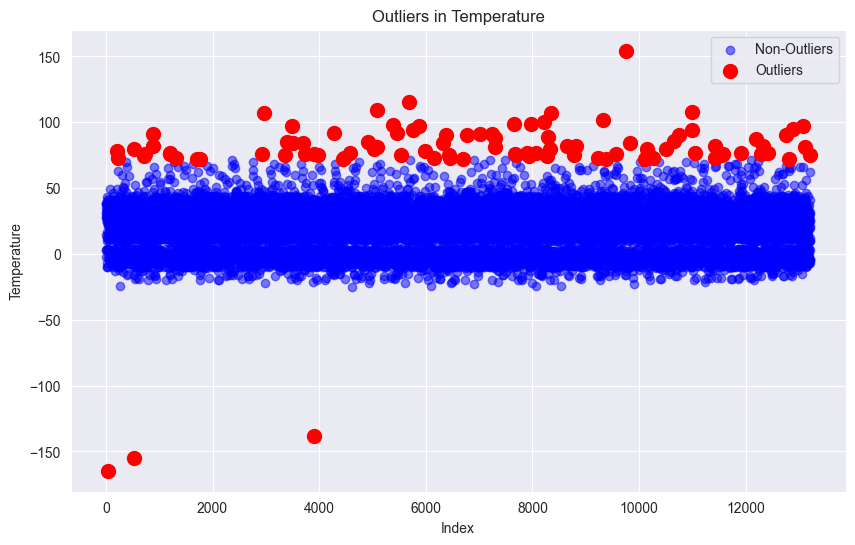

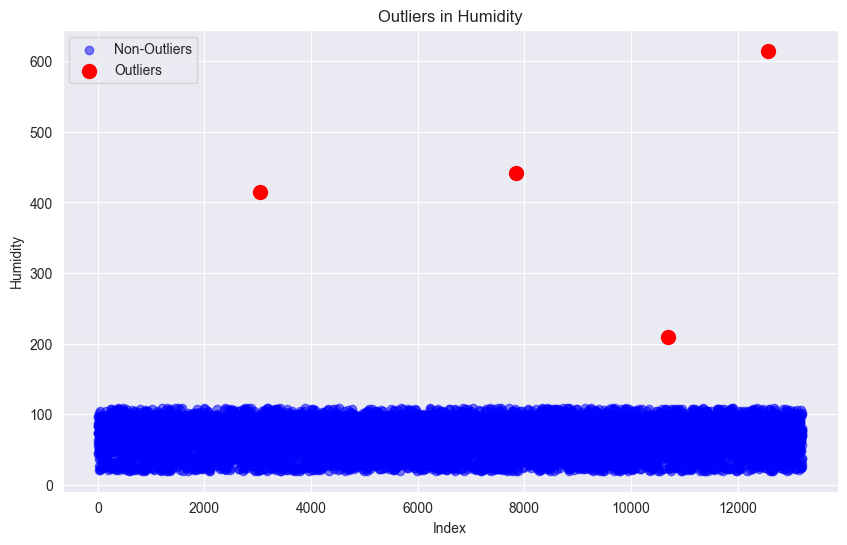

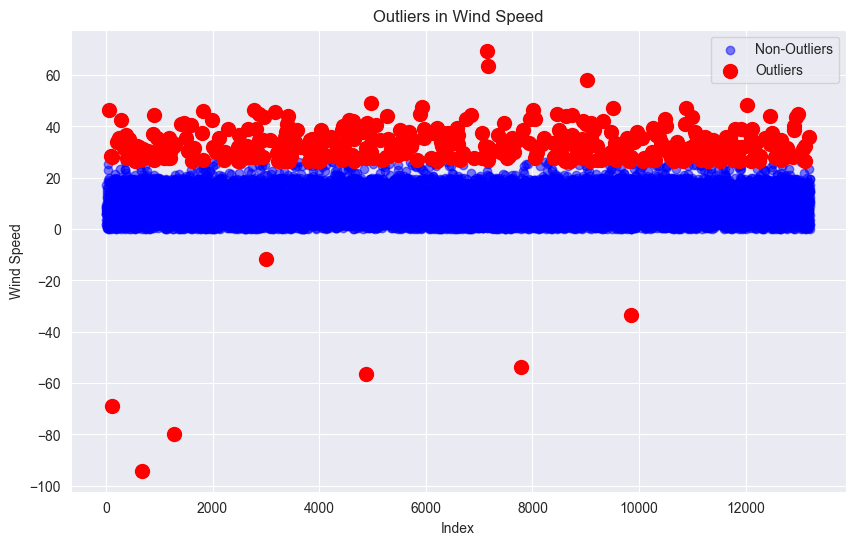

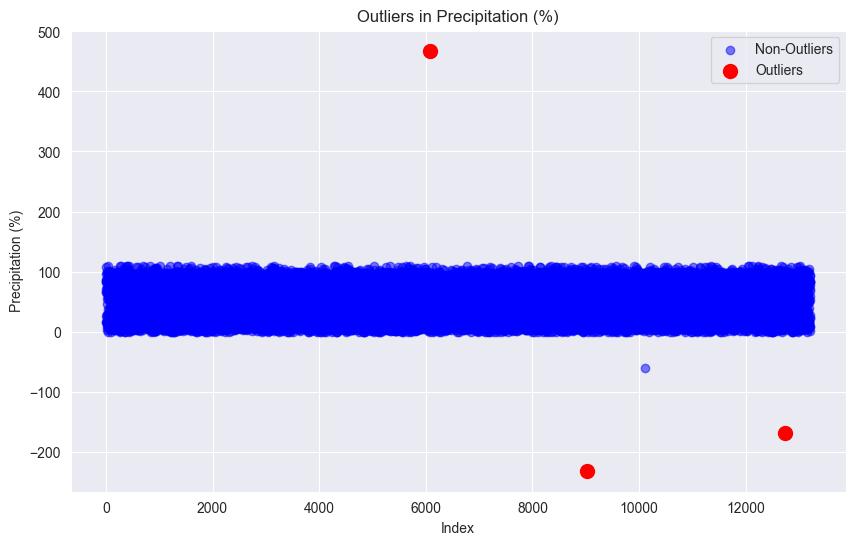

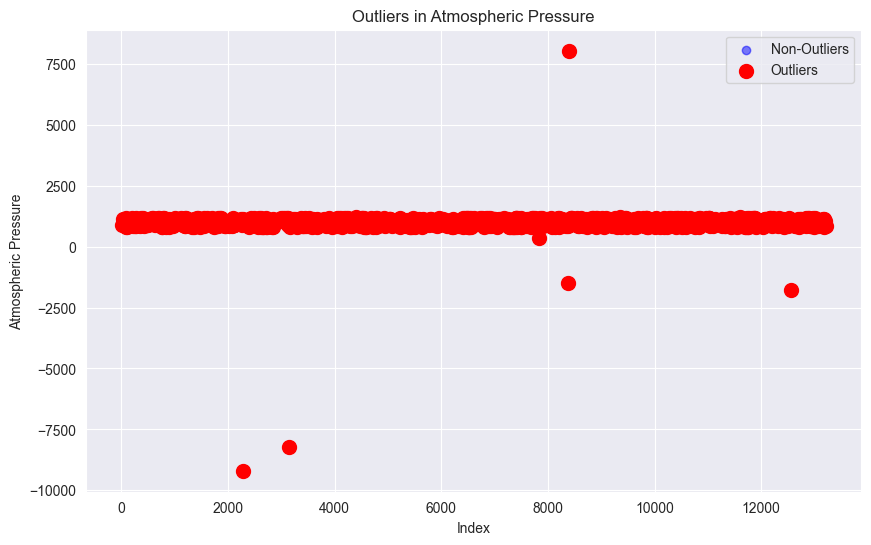

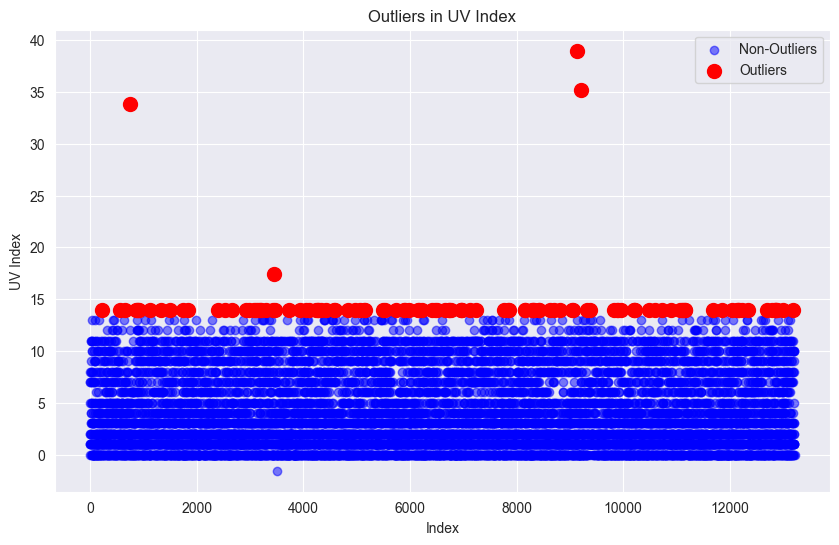

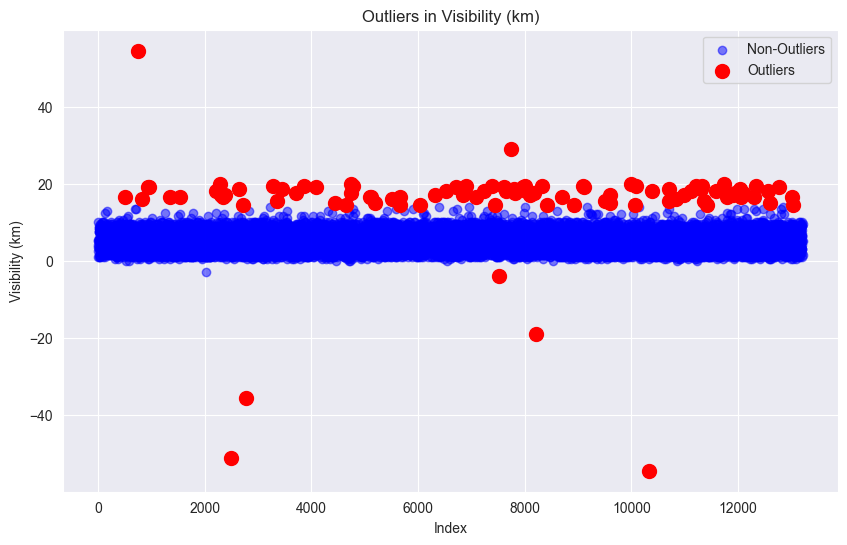

In [7]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

numeric_columns = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']

# iba test kvoli testovaniu outlierov kvoli zlemu vykreslenemu grafu pre Atmospheric Pressure
initial_count = weather_df['Atmospheric Pressure'].count()
print(initial_count)
outliers = detect_outliers(weather_df, 'Atmospheric Pressure')
print(outliers.shape[0])
weather_df_clean = weather_df.drop(outliers.index)
final_count = weather_df_clean['Atmospheric Pressure'].count()
print(final_count)

for column in numeric_columns:
    outliers = detect_outliers(weather_df, column)
    weather_df = weather_df.drop(outliers.index)
    
    plt.figure(figsize=(10,6))
    plt.scatter(weather_df.index, weather_df[column], color='blue', label='Non-Outliers', alpha=0.5)
    plt.scatter(outliers.index, outliers[column], color='red', label='Outliers', s=100)
    plt.title(f'Outliers in {column}')
    plt.xlabel("Index")
    plt.ylabel(column)
    plt.legend()
    plt.show()


In [8]:
# Odstranenie stlpca s velkym mnozstvom chybajucich hodnot (1333 nenulovych hodnot z priblizne 13000 zaznamov)
weather_df_clean = weather_df.drop(columns=["Irradiance"])

# Odstranenie riadkov, kde su NaN zaznamy
weather_df_clean = weather_df_clean.dropna()
weather_df_clean = weather_df_clean.drop_duplicates()

# sem si ulozime nezakodovane data, pre druhy blok ulohy
weather_df_cleanCoded = weather_df_clean.copy()

null_values = weather_df_clean.isnull().sum().sum()
duplicates = weather_df_clean.duplicated().sum()
samples = weather_df_clean.shape[0]

print(null_values, duplicates, samples)

label_encoder = LabelEncoder()
weather_df_clean['Weather Type'] = label_encoder.fit_transform(weather_df_clean['Weather Type'])

weather_df_encoded = pd.get_dummies(
    weather_df_clean, 
    columns=['Season', 'Cloud Cover', 'Location'],
    drop_first=False
)
pd.set_option('display.max_columns', None)
# Zobrazenie výsledných dát po zakódovaní
print(weather_df_encoded.head(15))

0 0 11300
    Temperature  Humidity  Wind Speed  Precipitation (%)  \
0          14.0      73.0         9.5               82.0   
1          39.0      96.0         8.5               71.0   
2          30.0      64.0         7.0               16.0   
3          38.0      83.0         1.5               82.0   
4          27.0      74.0        17.0               66.0   
5          32.0      55.0         3.5               26.0   
6          -2.0      97.0         8.0               86.0   
7           3.0      85.0         6.0               96.0   
8           3.0      83.0         6.0               66.0   
9          28.0      74.0         8.5              107.0   
11         38.0      43.0         2.0               16.0   
12         12.0      59.0        10.5               25.0   
13        -10.0      87.0        15.0               67.0   
14         24.0      21.0         3.5                8.0   
15         10.0      50.0         6.5               46.0   

    Atmospheric Pressure  UV 

In [9]:
X = weather_df_encoded.drop(columns=['Weather Type'])  # Všetky stĺpce okrem 'Weather Type'
Y = weather_df_encoded['Weather Type']  # Stĺpec 'Weather Type' (1D)

# Rozdelenie dát na trénovaciu, validačnú a testovaciu množinu
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)  # 60% na trénovanie
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)  # 20% na validáciu a 20% na testovanie

# Kontrola tvaru dát
print(X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape)

(7910, 19) (7910,) (1695, 19) (1695,) (1695, 19) (1695,)


In [10]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# from sklearn.preprocessing import RobustScaler
# 
# scaler = RobustScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_val_scaled = scaler.transform(X_val)
# X_test_scaled = scaler.transform(X_test)

Počet samplov v pôvodných dátach: 11300


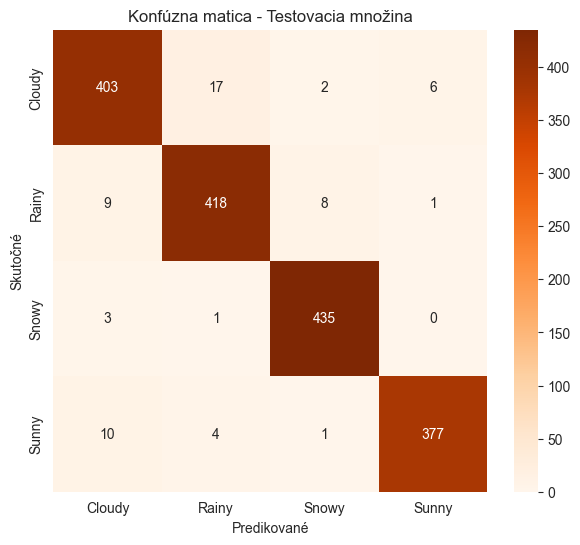

Testovacia presnosť modelu: 0.9634218289085545


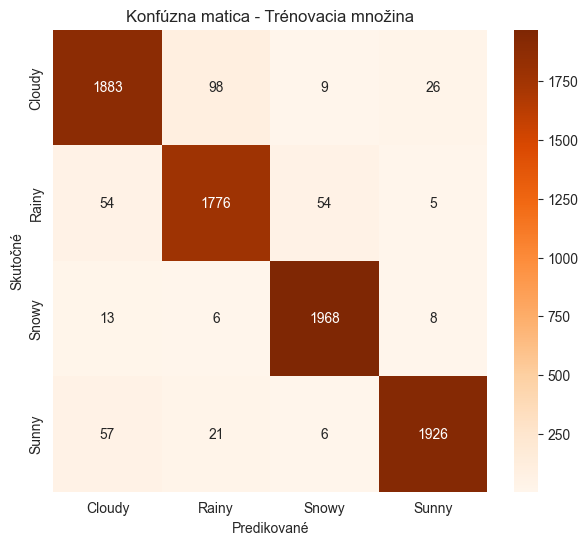

Tréningová presnosť modelu: 0.9548672566371681


In [11]:
print(f"Počet samplov v pôvodných dátach: {weather_df_encoded.shape[0]}")

# Trénovanie modelu pomocou logistickej regresie
model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, Y_train)

# Predikcia pre testovaciu množinu
y_test_pred = model.predict(X_test_scaled)
# Predikcia pre tréningovú množinu
y_train_pred = model.predict(X_train_scaled)

# Vytvorenie konfúznej matice pre testovaciu množinu
conf_matrix_test = confusion_matrix(Y_test, y_test_pred)
# Vytvorenie konfúznej matice pre tréningovú množinu
conf_matrix_train = confusion_matrix(Y_train, y_train_pred)

# Zobrazenie konfúznej matice testovacej množiny
plt.figure(figsize=(7, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Oranges', xticklabels=['Cloudy', 'Rainy', 'Snowy', 'Sunny'], yticklabels=['Cloudy', 'Rainy', 'Snowy', 'Sunny'])
plt.title("Konfúzna matica - Testovacia množina")
plt.xlabel("Predikované")
plt.ylabel("Skutočné")
plt.show()
# Určenie presnosti modelu pre testovaciu množinu
accuracy = accuracy_score(Y_test, y_test_pred)
print(f"Testovacia presnosť modelu: {accuracy}")

# Zobrazenie konfúznej matice tréningovej množiny
plt.figure(figsize=(7, 6))
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Oranges', xticklabels=['Cloudy', 'Rainy', 'Snowy', 'Sunny'], yticklabels=['Cloudy', 'Rainy', 'Snowy', 'Sunny'])
plt.title("Konfúzna matica - Trénovacia množina")
plt.xlabel("Predikované")
plt.ylabel("Skutočné")
plt.show()

# Určenie presnosti modelu pre tréningovú množinu
train_accuracy = accuracy_score(Y_train, y_train_pred)
print(f"Tréningová presnosť modelu: {train_accuracy}")

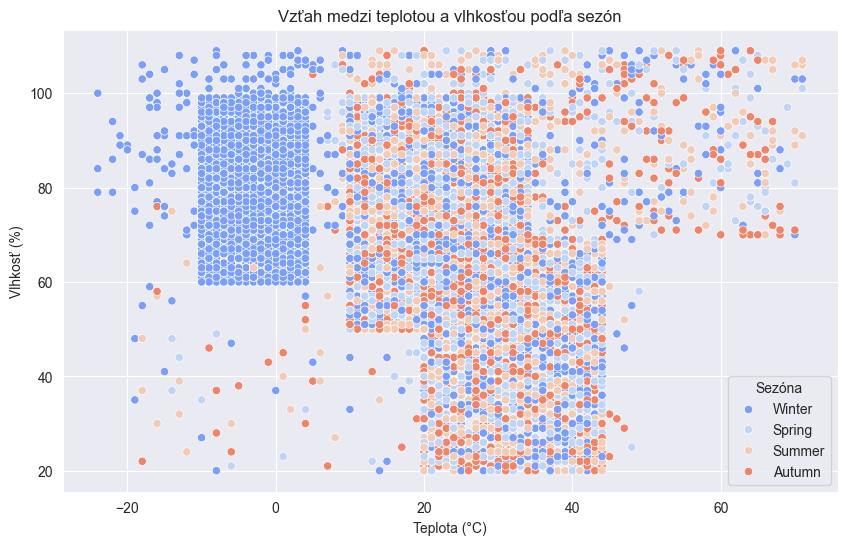

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=weather_df_cleanCoded['Temperature'], 
                y=weather_df_cleanCoded['Humidity'], 
                hue=weather_df_cleanCoded['Season'], palette='coolwarm')
plt.title('Vzťah medzi teplotou a vlhkosťou podľa sezón')
plt.xlabel('Teplota (°C)')
plt.ylabel('Vlhkosť (%)')
plt.legend(title='Sezóna')
plt.show()

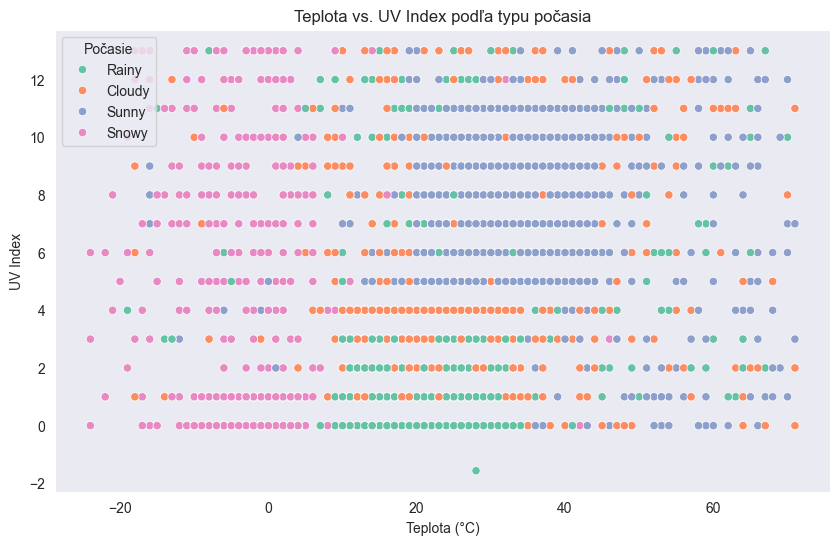

In [13]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=weather_df_cleanCoded['Temperature'], 
                y=weather_df_cleanCoded['UV Index'], 
                hue=weather_df_cleanCoded['Weather Type'], palette='Set2')
plt.title('Teplota vs. UV Index podľa typu počasia')
plt.xlabel('Teplota (°C)')
plt.ylabel('UV Index')
plt.legend(title='Počasie')
plt.grid()
plt.show()


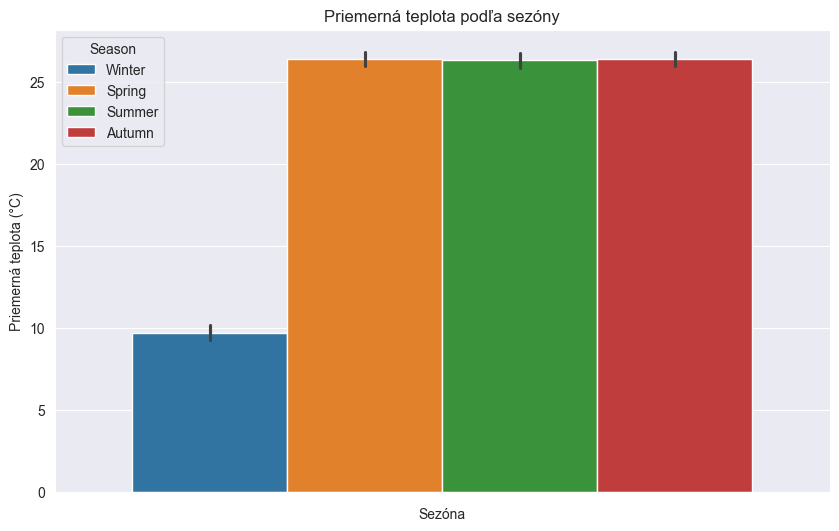

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(data=weather_df_cleanCoded, hue='Season', y='Temperature',)
plt.title('Priemerná teplota podľa sezóny')
plt.xlabel('Sezóna')
plt.ylabel('Priemerná teplota (°C)')
plt.show()


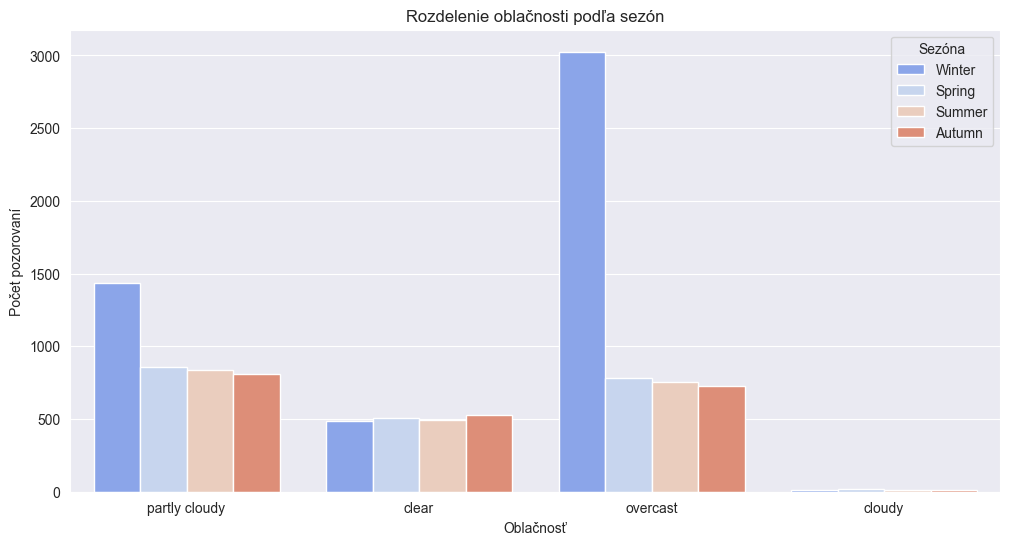

In [15]:
plt.figure(figsize=(12, 6))
sns.countplot(data=weather_df_cleanCoded, x='Cloud Cover', hue='Season', palette='coolwarm')
plt.title('Rozdelenie oblačnosti podľa sezón')
plt.xlabel('Oblačnosť')
plt.ylabel('Počet pozorovaní')
plt.legend(title='Sezóna')
plt.show()


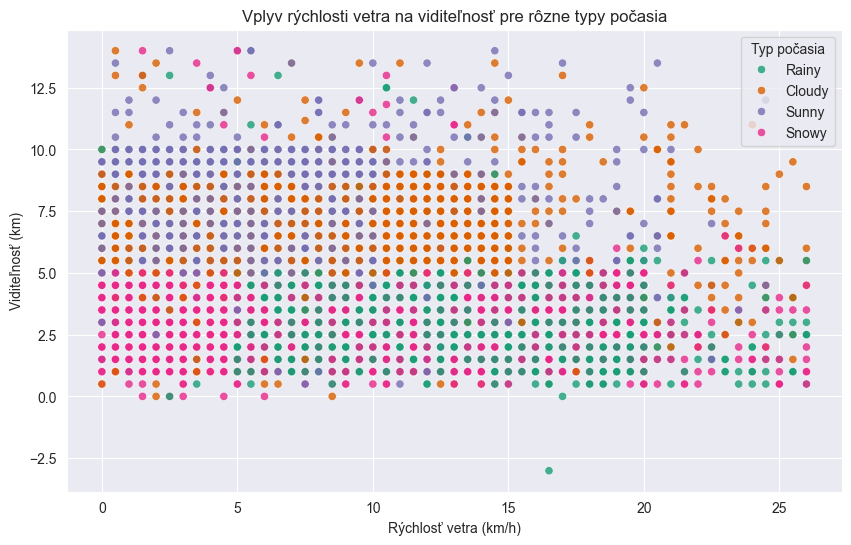

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=weather_df_cleanCoded['Wind Speed'], 
                y=weather_df_cleanCoded['Visibility (km)'], 
                hue=weather_df_cleanCoded['Weather Type'], 
                palette='Dark2', 
                alpha=0.8)
plt.title('Vplyv rýchlosti vetra na viditeľnosť pre rôzne typy počasia')
plt.xlabel('Rýchlosť vetra (km/h)')
plt.ylabel('Viditeľnosť (km)')
plt.legend(title='Typ počasia')
plt.grid(True)
plt.show()

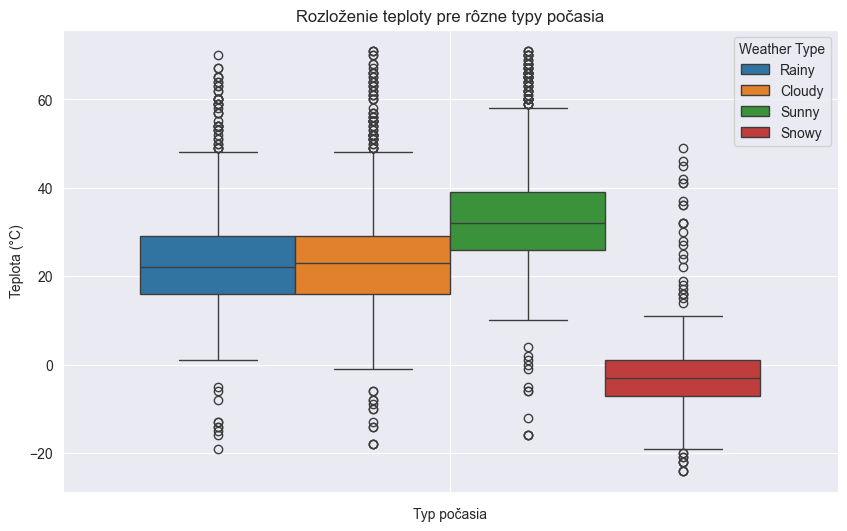

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(hue=weather_df_cleanCoded['Weather Type'], 
            y=weather_df_cleanCoded['Temperature'])
plt.title('Rozloženie teploty pre rôzne typy počasia')
plt.xlabel('Typ počasia')
plt.ylabel('Teplota (°C)')
plt.grid(True)
plt.show()


Epoch 1/150
495/495 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5469 - loss: 1.0491 - val_accuracy: 0.9186 - val_loss: 0.3592
Epoch 2/150
495/495 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9409 - loss: 0.2566 - val_accuracy: 0.9475 - val_loss: 0.2251
Epoch 3/150
495/495 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9513 - loss: 0.1876 - val_accuracy: 0.9510 - val_loss: 0.2124
Epoch 4/150
495/495 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9554 - loss: 0.1649 - val_accuracy: 0.9440 - val_loss: 0.2120
Epoch 5/150
495/495 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9582 - loss: 0.1541 - val_accuracy: 0.9546 - val_loss: 0.1993
Epoch 6/150
495/495 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9581 - loss: 0.1499 - val_accuracy: 0.9510 - val_loss: 0.1992
Epoch 7/150
495/495 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9622 - loss: 0.1362 - val_accuracy: 0.9487 - val_loss: 0.1887
Epoch 8/150
495/495 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9629 - loss: 0.1329 - val_accu

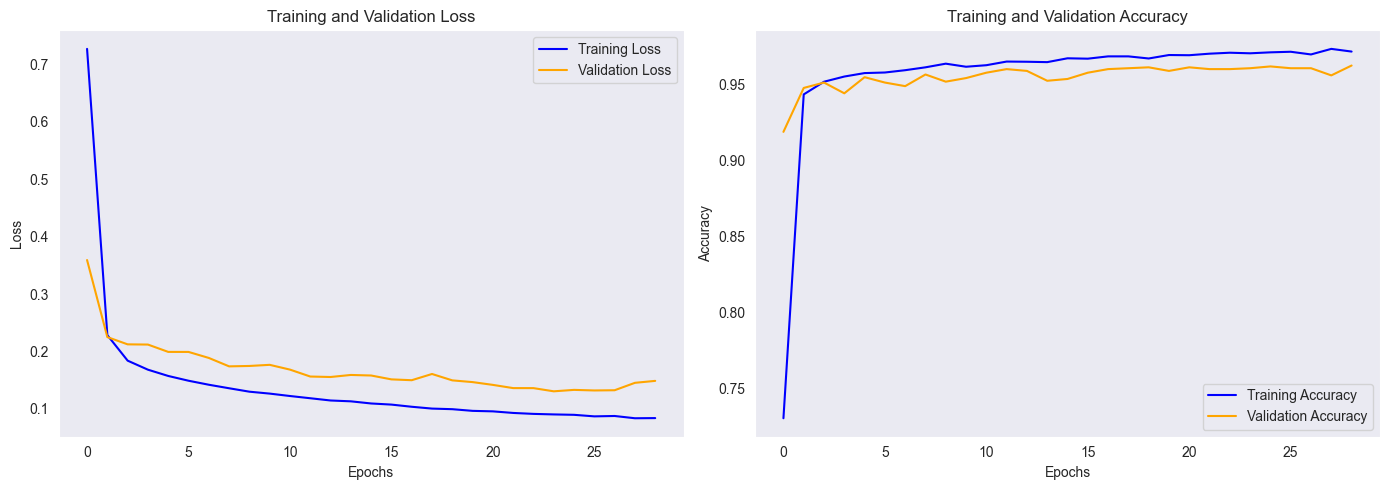

248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step


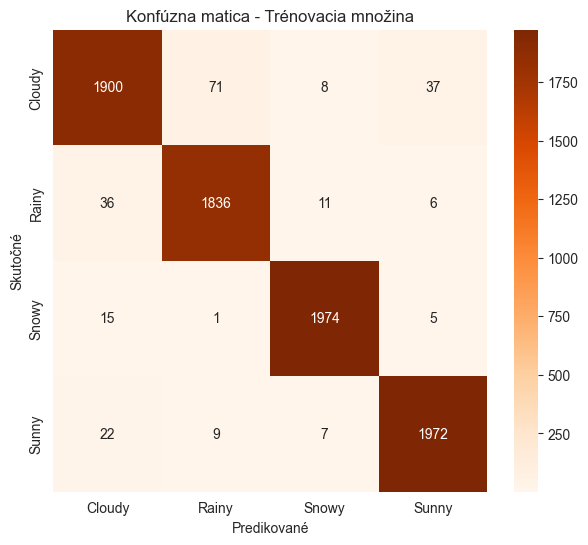

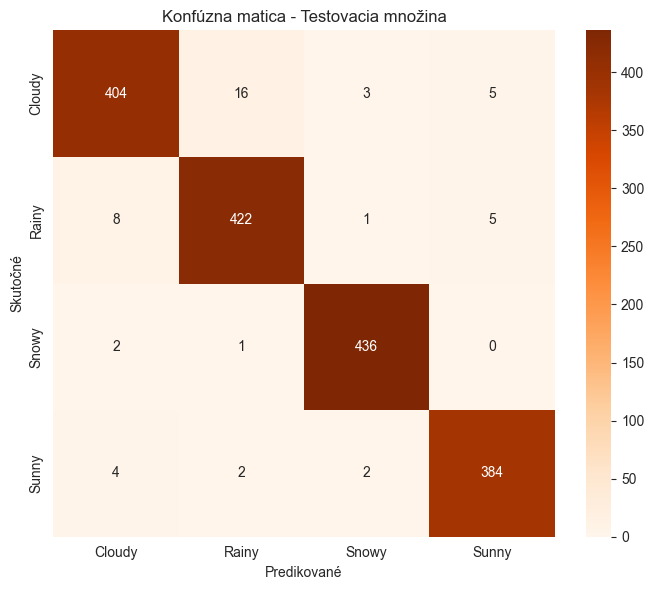

In [18]:

import numpy as np

# X = weather_df_encoded.drop(columns=['Weather Type'])  # Všetky stĺpce okrem 'Weather Type'
# Y = weather_df_encoded['Weather Type']  # Stĺpec 'Weather Type' (1D)
# 
# # Rozdelenie dát na trénovaciu, validačnú a testovaciu množinu
# X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.4, random_state=42)  # 60% na trénovanie
# X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)  # 20% na validáciu a 20% na testovanie
 
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_val_scaled = scaler.transform(X_val)
# X_test_scaled = scaler.transform(X_test)

import tensorflow as tf
from keras.src.callbacks import EarlyStopping
from keras.src.optimizers import Adam

# Definícia modelu (počet vstupných dát)
input_dim = X_train_scaled.shape[1]

# print(len(X_train))
# print(X_train.shape[1])
# print(len(np.unique(Y_train)))

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(input_dim,)))
model.add(tf.keras.layers.Dense(32, activation='relu'))
# model.add(tf.keras.layers.Dropout(0.5)) 
model.add(tf.keras.layers.Dense(16, activation='relu')) 
# model.add(tf.keras.layers.Dropout(0.5)) 
model.add(tf.keras.layers.Dense(8, activation='relu')) 
# model.add(tf.keras.layers.Dropout(0.5)) 
model.add(tf.keras.layers.Dense(4, activation='softmax')) 

optimizer = Adam(learning_rate=0.001)

# Kompilácia modelu
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Trénovanie modelu
history = model.fit(X_train_scaled, Y_train,
                    epochs=150, 
                    batch_size=16,
                    verbose=1,
                    validation_data=(X_val_scaled, Y_val),
                    callbacks=[early_stopping])

# Presnost na trenovacich datach
train_loss, train_accuracy = model.evaluate(X_train_scaled, Y_train)
print(f'Trénovacia presnosť modelu: {train_accuracy:.6f}')

# Presnost na testovacich datach
test_loss, test_accuracy = model.evaluate(X_test_scaled, Y_test)
print(f'Testovacia presnosť modelu: {test_accuracy:.6f}')

plt.figure(figsize=(14, 5))

# Tréningová a validačná strata
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# Tréningová a validačná presnosť
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


# Predpovedanie výstupov pre trénovaciu a testovaciu množinu
Y_train_pred = model.predict(X_train_scaled)
Y_test_pred = model.predict(X_test_scaled)

# Pre prevod pravdepodobností na predikcie vzhľadom na sparse_categorical_crossentropy
Y_train_pred_classes = np.argmax(Y_train_pred, axis=1)
Y_test_pred_classes = np.argmax(Y_test_pred, axis=1)

# Vytvorenie konfúznej matice pre trénovaciu množinu
cm_train = confusion_matrix(Y_train, Y_train_pred_classes)
# Vytvorenie konfúznej matice pre testovaciu množinu
cm_test = confusion_matrix(Y_test, Y_test_pred_classes)


plt.figure(figsize=(7, 6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Oranges', xticklabels=['Cloudy', 'Rainy', 'Snowy', 'Sunny'], yticklabels=['Cloudy', 'Rainy', 'Snowy', 'Sunny'])
plt.title("Konfúzna matica - Trénovacia množina")
plt.xlabel("Predikované")
plt.ylabel("Skutočné")

plt.figure(figsize=(7, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', xticklabels=['Cloudy', 'Rainy', 'Snowy', 'Sunny'], yticklabels=['Cloudy', 'Rainy', 'Snowy', 'Sunny'])
plt.title("Konfúzna matica - Testovacia množina")
plt.xlabel("Predikované")
plt.ylabel("Skutočné")

plt.tight_layout()
plt.show()


In [19]:
# BONUS - porovnanie ineho modelu z kniznice Sklearn

# Rozdelenie dát na trénovaciu, validačnú a testovaciu množinu
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Definícia modelu K-Nearest Neighbors s K=5
knn_model = KNeighborsClassifier(n_neighbors=5)

# Trénovanie modelu
knn_model.fit(X_train_scaled, Y_train)

# Predikcia na trénovacej a testovacej množine
y_train_pred_knn = knn_model.predict(X_train_scaled)
y_test_pred_knn = knn_model.predict(X_test_scaled)

# Vyhodnotenie presnosti
train_accuracy_knn = accuracy_score(Y_train, y_train_pred_knn)
test_accuracy_knn = accuracy_score(Y_test, y_test_pred_knn)
print(f"Trénovacia presnosť modelu: {train_accuracy_knn:.6f}")
print(f"Testovacia presnosť modelu: {test_accuracy_knn:.6f}")


# Vytvorenie konfúznej matice pre testovaciu množinu
# conf_matrix_knn_test = confusion_matrix(Y_test, y_test_pred_knn)
# Vytvorenie konfúznej matice pre tréningovú množinu
# conf_matrix_knn_train = confusion_matrix(Y_train, y_train_pred_knn)

# Zobrazenie konfúznej matice testovacej množiny
# plt.figure(figsize=(7, 6))
# sns.heatmap(conf_matrix_knn_test, annot=True, fmt='d', cmap='Oranges', xticklabels=['Cloudy', 'Rainy', 'Snowy', 'Sunny'], yticklabels=['Cloudy', 'Rainy', 'Snowy', 'Sunny'])
# plt.title("Konfúzna matica - Testovacia množina")
# plt.xlabel("Predikované")
# plt.ylabel("Skutočné")
# 
# # Zobrazenie konfúznej matice tréningovej množiny
# plt.figure(figsize=(7, 6))
# sns.heatmap(conf_matrix_knn_train, annot=True, fmt='d', cmap='Oranges', xticklabels=['Cloudy', 'Rainy', 'Snowy', 'Sunny'], yticklabels=['Cloudy', 'Rainy', 'Snowy', 'Sunny'])
# plt.title("Konfúzna matica - Trénovacia množina")
# plt.xlabel("Predikované")
# plt.ylabel("Skutočné")
# plt.show()


Trénovacia presnosť modelu: 0.963843
Testovacia presnosť modelu: 0.964602


In [20]:
from sklearn.ensemble import RandomForestClassifier

# Trénovanie Random Forest modelu
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_scaled, Y_train)

# Predikcia na tréningovej a testovacej množine
y_train_pred_rf = model_rf.predict(X_train_scaled)
y_test_pred_rf = model_rf.predict(X_test_scaled)

# Vyhodnotenie presnosti na tréningovej a testovacej množine
train_accuracy_rf = accuracy_score(Y_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(Y_test, y_test_pred_rf)

print(f"Trénovacia presnosť modelu Random Forest: {train_accuracy_rf:.6f}")
print(f"Testovacia presnosť modelu Random Forest: {test_accuracy_rf:.6f}")


Trénovacia presnosť modelu Random Forest: 1.000000
Testovacia presnosť modelu Random Forest: 0.982301


Epoch 1/150
396/396 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4937 - loss: 1.0481 - val_accuracy: 0.9027 - val_loss: 0.3338
Epoch 2/150
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9229 - loss: 0.2883 - val_accuracy: 0.9279 - val_loss: 0.2442
Epoch 3/150
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9388 - loss: 0.2357 - val_accuracy: 0.9463 - val_loss: 0.1851
Epoch 4/150
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9457 - loss: 0.1896 - val_accuracy: 0.9621 - val_loss: 0.1619
Epoch 5/150
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9535 - loss: 0.1686 - val_accuracy: 0.9570 - val_loss: 0.1588
Epoch 6/150
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9515 - loss: 0.1739 - val_accuracy: 0.9589 - val_loss: 0.1523
Epoch 7/150
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9528 - loss: 0.1646 - val_accuracy: 0.9633 - val_loss: 0.1418
Epoch 8/150
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9539 - loss: 0.1639 - val_accu

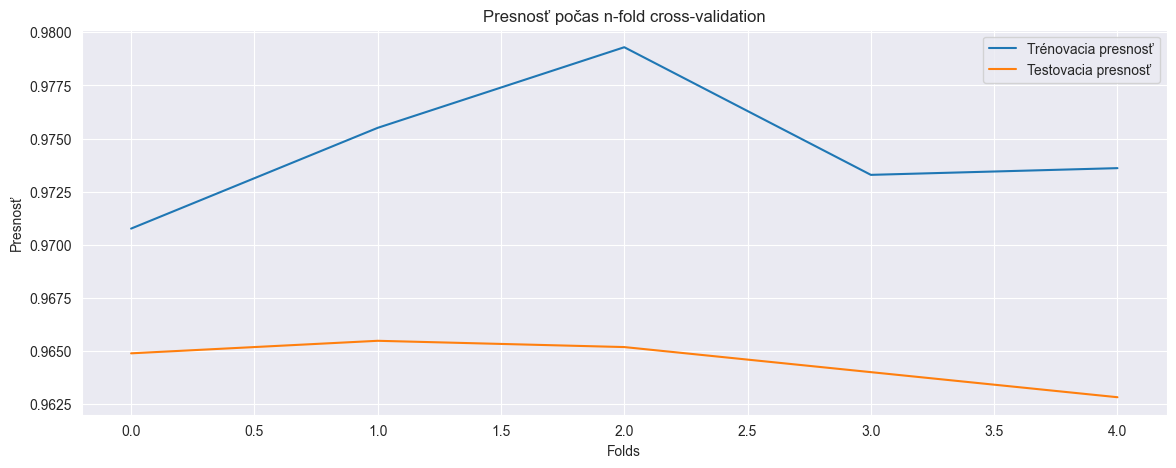

In [21]:
import numpy as np
import tensorflow as tf
from keras.src.callbacks import EarlyStopping
from keras.src.optimizers import Adam
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

X = weather_df_encoded.drop(columns=['Weather Type'])  # Všetky stĺpce okrem 'Weather Type'
Y = weather_df_encoded['Weather Type']  # Stĺpec 'Weather Type' (1D)

# Rozdelenie dát na trénovaciu a testovaciu množinu (bez validačnej)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)  # 70% na trénovanie, 30% na testovanie

# Normalizácia - škálovanie
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# N-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_accuracies = []
test_accuracies = []

for train_index, val_index in kf.split(X_train_scaled):
    X_train_fold, X_val_fold = X_train_scaled[train_index], X_train_scaled[val_index]
    Y_train_fold, Y_val_fold = Y_train.iloc[train_index], Y_train.iloc[val_index]
    # Vytvorenie modelu
    input_dim = X_train_fold.shape[1]
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))
    model.add(tf.keras.layers.Dense(32, activation='relu'))
    model.add(tf.keras.layers.Dense(16, activation='relu'))
    model.add(tf.keras.layers.Dense(8, activation='relu'))
    model.add(tf.keras.layers.Dense(4, activation='softmax'))

    optimizer = Adam(learning_rate=0.001)

    # Kompilácia modelu
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Trénovanie modelu
    model.fit(X_train_fold, Y_train_fold,
              epochs=150, 
              batch_size=16,
              verbose=1,
              validation_data=(X_val_fold, Y_val_fold),
              callbacks=[early_stopping])

    val_loss, val_accuracy = model.evaluate(X_val_fold, Y_val_fold)
    train_loss, train_accuracy = model.evaluate(X_train_fold, Y_train_fold)

    train_accuracies.append(train_accuracy)
    
    # Presnosť na testovacích dátach
    test_loss, test_accuracy = model.evaluate(X_test_scaled, Y_test)
    test_accuracies.append(test_accuracy)

# Priemerné presnosti
print(f'Priemerná tréningová presnosť: {np.mean(train_accuracies):.6f}')
print(f'Priemerná testovacia presnosť: {np.mean(test_accuracies):.6f}')

# Vykreslenie presnosti
plt.figure(figsize=(14, 5))
plt.plot(train_accuracies, label='Trénovacia presnosť')
plt.plot(test_accuracies, label='Testovacia presnosť')
plt.title('Presnosť počas n-fold cross-validation')
plt.xlabel('Folds')
plt.ylabel('Presnosť')
plt.legend()
plt.show()